In [1]:
import openmc
import openmc.model
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import math

def generate_carem25_assembly(enrichment=0.031, boron_ppm=0.0, particles=10000, batches=50):
    """
    CAREM-25 Altıgen (Hexagonal) Yakıt Demeti Modellemesi.
    Toplam 127 Yuva: 108 Yakıt, 18 Kılavuz Tüpü, 1 Enstrümantasyon.
    """
    print(f"CAREM-25 Altıgen Modeli Oluşturuluyor (Zenginlik: %{enrichment*100})")

    # 1. MALZEME TANIMLAMALARI (O16 İZOTOPUYLA)
    fuel = openmc.Material(name='CAREM_UO2')
    fuel.set_density('g/cm3', 10.42)
    m_u = enrichment * 235.04 + (1.0 - enrichment) * 238.05
    m_o2 = 2 * 15.995 
    m_uo2 = m_u + m_o2
    fuel.add_nuclide('U235', enrichment * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('U238', (1.0 - enrichment) * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('O16', m_o2 / m_uo2, 'wo')

    clad = openmc.Material(name='CAREM_Zircaloy4')
    clad.set_density('g/cm3', 6.56)
    clad.add_element('Zr', 0.9823, 'wo')
    clad.add_element('Sn', 0.0145, 'wo')
    clad.add_element('Fe', 0.0021, 'wo')
    clad.add_element('Cr', 0.0011, 'wo')

    helium = openmc.Material(name='CAREM_Gap_He')
    helium.set_density('g/cm3', 0.001598)
    helium.add_element('He', 1.0)

    water = openmc.Material(name='CAREM_Water')
    water.set_density('g/cm3', 0.740582)
    water.temperature = 566.5 
    
    boron_wt = boron_ppm * 1e-6
    water_wt = 1.0 - boron_wt
    m_H2O = 2 * 1.008 + 15.995
    water.add_element('H', water_wt * (2 * 1.008) / m_H2O, 'wo')
    water.add_nuclide('O16', water_wt * 15.995 / m_H2O, 'wo')
    water.add_element('B', boron_wt, 'wo')

    materials = openmc.Materials([fuel, clad, helium, water])
    materials.export_to_xml()

    # 2. GEOMETRİK BOYUTLAR (Cm)
    pitch = 1.38
    r_pellet = openmc.ZCylinder(r=0.380)
    r_gap = openmc.ZCylinder(r=0.3875)
    r_clad = openmc.ZCylinder(r=0.450)
    
    # Kılavuz tüpler (Yakıt çubuklarıyla aynı dış çapı referans alırız)
    r_gt_in = openmc.ZCylinder(r=0.380)
    r_gt_out = openmc.ZCylinder(r=0.450)

    # Evrenler
    c_fuel = openmc.Cell(fill=fuel, region=-r_pellet)
    c_gap = openmc.Cell(fill=helium, region=+r_pellet & -r_gap)
    c_clad = openmc.Cell(fill=clad, region=+r_gap & -r_clad)
    c_water = openmc.Cell(fill=water, region=+r_clad)
    F = openmc.Universe(cells=[c_fuel, c_gap, c_clad, c_water]) # Fuel Universe

    c_gt_inner = openmc.Cell(fill=water, region=-r_gt_in)
    c_gt_clad = openmc.Cell(fill=clad, region=+r_gt_in & -r_gt_out)
    c_gt_water = openmc.Cell(fill=water, region=+r_gt_out)
    G = openmc.Universe(cells=[c_gt_inner, c_gt_clad, c_gt_water]) # Guide Tube Universe

    # 3. ALTIGEN MATRİS (HEXLATTICE) HALKALARI
    # Toplam 108 Yakıt, 19 Su Tüpü (18 Kılavuz + 1 Merkez) = 127 Yuva
    # En dıştan içe doğru tanımlanır.
    ring7 = [F] * 36
    ring6 = [G, F, F, F, F] * 6  # 30 eleman (6 adet Kılavuz Tüp eşit dağıtıldı)
    ring5 = [G, F, F, F] * 6     # 24 eleman (6 adet Kılavuz Tüp eşit dağıtıldı)
    ring4 = [G, F, F] * 6        # 18 eleman (6 adet Kılavuz Tüp eşit dağıtıldı)
    ring3 = [F] * 12
    ring2 = [F] * 6
    ring1 = [G]                  # Merkez Enstrümantasyon Tüpü

    lattice = openmc.HexLattice()
    lattice.center = (0.0, 0.0)
    lattice.pitch = [pitch]
    # OpenMC HexLattice'i listelerden oluşan bir liste alır (En dış halkadan başlar)
    lattice.universes = [ring7, ring6, ring5, ring4, ring3, ring2, ring1]
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    # Altıgen dış sınır (Reflective)
    # Aapotem (Merkezden düz kenara mesafe) = 6.5 * pitch
    apothem = 6.5 * pitch
    edge_len = (apothem * 2) / math.sqrt(3) 
    
    # openmc.model.HexagonalPrism ile dış sınır prizması
    hex_prism = openmc.model.HexagonalPrism(orientation='y', edge_length=edge_len, boundary_type='reflective')
    
    # CAREM-25 Aktif Yükseklik: 140.0 cm (-70 den +70'e)
    min_z = openmc.ZPlane(z0=-70.0, boundary_type='reflective')
    max_z = openmc.ZPlane(z0=70.0, boundary_type='reflective')

    core_box = -hex_prism & +min_z & -max_z
    main_cell = openmc.Cell(fill=lattice, region=core_box)
    geometry = openmc.Geometry([main_cell])
    geometry.export_to_xml()

    # 4. AYARLAR VE SENSÖRLER
    settings = openmc.Settings()
    settings.batches = batches
    settings.inactive = max(10, int(batches * 0.2))
    settings.particles = particles
    settings.temperature = {'method': 'interpolation'}
    
    spatial_dist = openmc.stats.Box((-apothem, -apothem, -70), (apothem, apothem, 70))
    settings.source = openmc.IndependentSource(space=spatial_dist, constraints={'fissionable': True})
    settings.export_to_xml()

    print("CAREM-25 Altıgen XML dosyaları üretildi.")
    return apothem

In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

apothem = generate_carem25_assembly(enrichment=0.031, boron_ppm=0.0, particles=10000, batches=60)

print("\nGelişmiş Sensörler (Tallies) Kuruluyor.")

#  ENERJİ SPEKTRUMU SENSÖRÜ (Logaritmik Dağılım)
energy_bins = np.logspace(-5, 7.3, 500)
energy_filter = openmc.EnergyFilter(energy_bins)
spectrum_tally = openmc.Tally(name='Notron_Spektrumu')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

#  ISI HARİTALARI VE PİN GÜCÜ İÇİN 170x170 İNCE AĞ (MESH)
spatial_mesh = openmc.RegularMesh()
spatial_mesh.dimension = [170, 170]
spatial_mesh.lower_left = [-apothem*1.1, -apothem*1.1] 
spatial_mesh.upper_right = [apothem*1.1, apothem*1.1]

spatial_tally = openmc.Tally(name='Uzamsal_Haritalar')
spatial_tally.filters = [openmc.MeshFilter(spatial_mesh)]
spatial_tally.scores = ['flux', 'fission', 'absorption', 'kappa-fission']

# KÜRESEL REAKSİYON İSTATİSTİKLERİ SENSÖRÜ (Tüm Reaktör)
reaction_tally = openmc.Tally(name='Global_Reaksiyonlar')
reaction_tally.scores = ['(n,2n)', '(n,gamma)']

# SHANNON ENTROPİSİ (Kaynak Yakınsaması)
entropy_mesh = openmc.RegularMesh()
entropy_mesh.dimension = [20, 20, 1]
entropy_mesh.lower_left = [-apothem, -apothem, -70.0]
entropy_mesh.upper_right = [apothem, apothem, 70.0]

settings = openmc.Settings.from_xml()
settings.entropy_mesh = entropy_mesh
settings.export_to_xml()

# Sensörleri XML'e kaydet
tallies = openmc.Tallies([spectrum_tally, spatial_tally, reaction_tally])
tallies.export_to_xml()

#  SİMÜLASYONU BAŞLAT
print("\n--- CAREM-25 K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---\n")
openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
openmc.run(output=True) 

CAREM-25 Altıgen Modeli Oluşturuluyor (Zenginlik: %3.1)
CAREM-25 Altıgen XML dosyaları üretildi.

Gelişmiş Sensörler (Tallies) Kuruluyor.

--- CAREM-25 K-EIGENVALUE VE ANALİZ SİMÜLASYONU BAŞLIYOR ---

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ###########

CAREM-25 Altıgen Geometrisi Çiziliyor.
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%

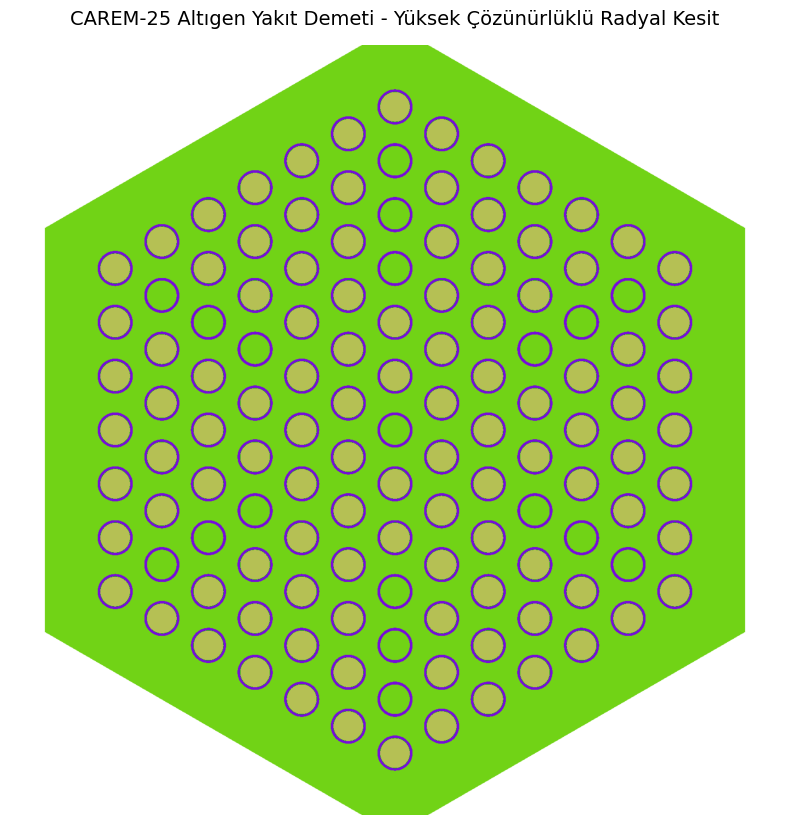

In [3]:
import matplotlib.image as mpimg

print("CAREM-25 Altıgen Geometrisi Çiziliyor.")

plot = openmc.Plot()
plot.filename = 'carem25_radial_plot'
width = apothem * 2.2
plot.width = (width, width)
plot.pixels = (1500, 1500) 
plot.basis = 'xy'
plot.origin = (0.0, 0.0, 0.0)
plot.color_by = 'material'

plots = openmc.Plots([plot])
plots.export_to_xml()
openmc.plot_geometry()

try:
    img = mpimg.imread('carem25_radial_plot.png')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('CAREM-25 Altıgen Yakıt Demeti - Yüksek Çözünürlüklü Radyal Kesit', fontsize=14, pad=15)
    plt.show()
except FileNotFoundError:
    print("Çizim dosyası bulunamadı.")


Sonuçlar HDF5 Dosyasından Analiz Ediliyor.



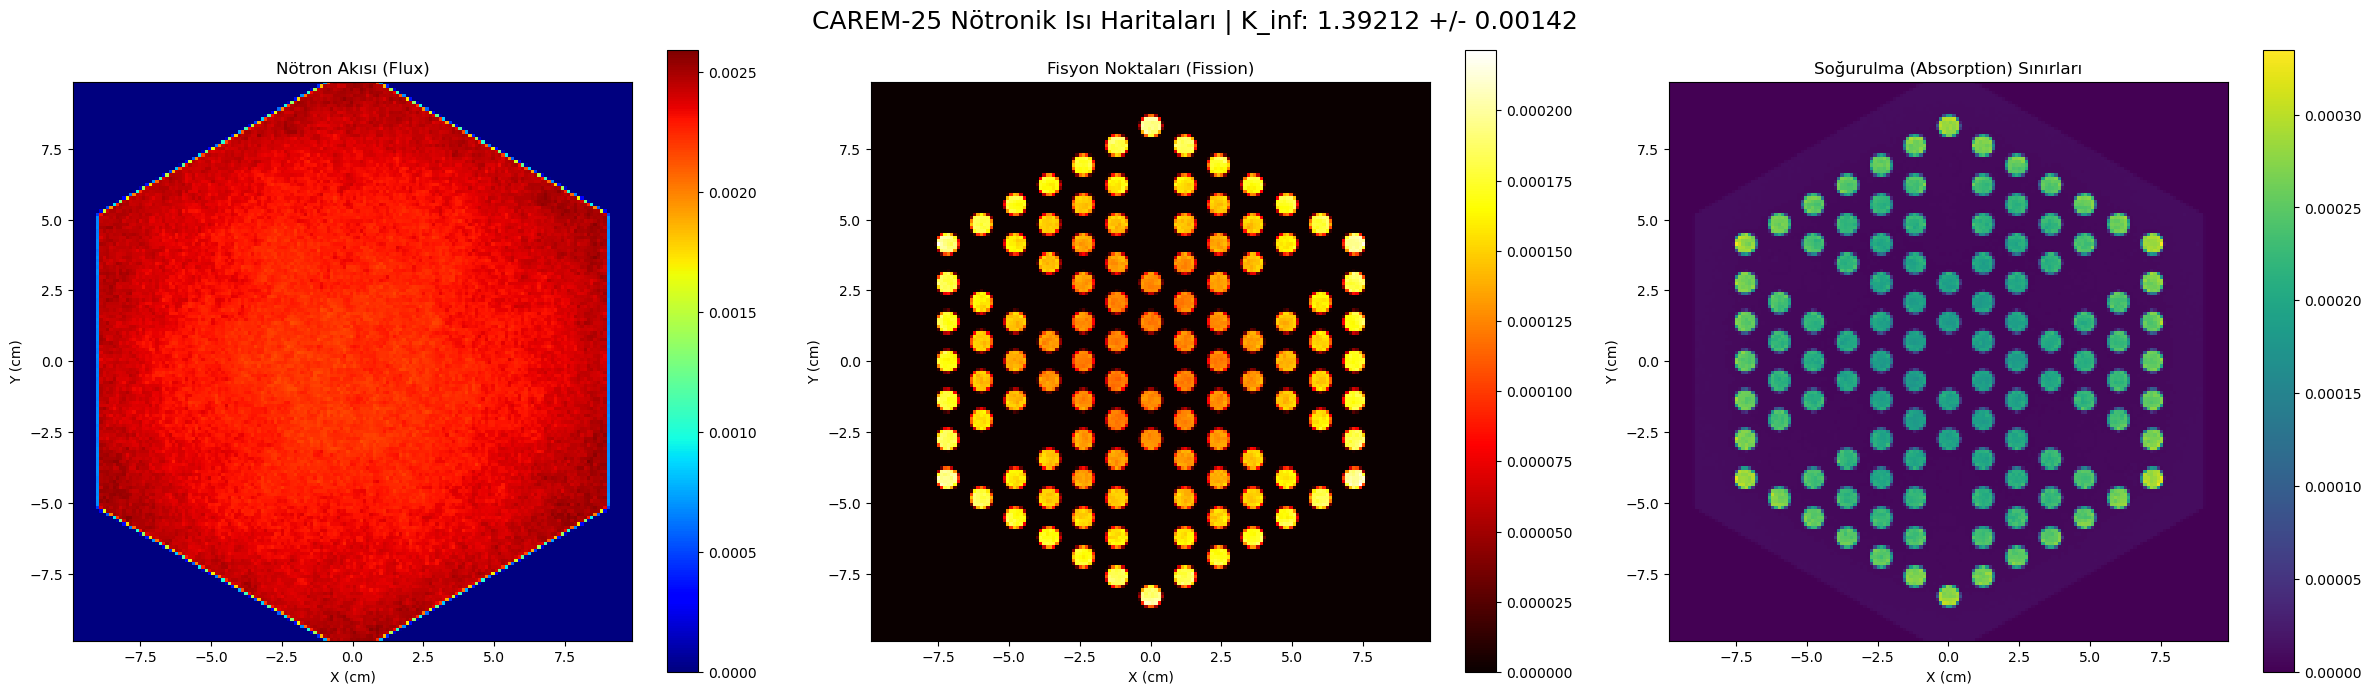

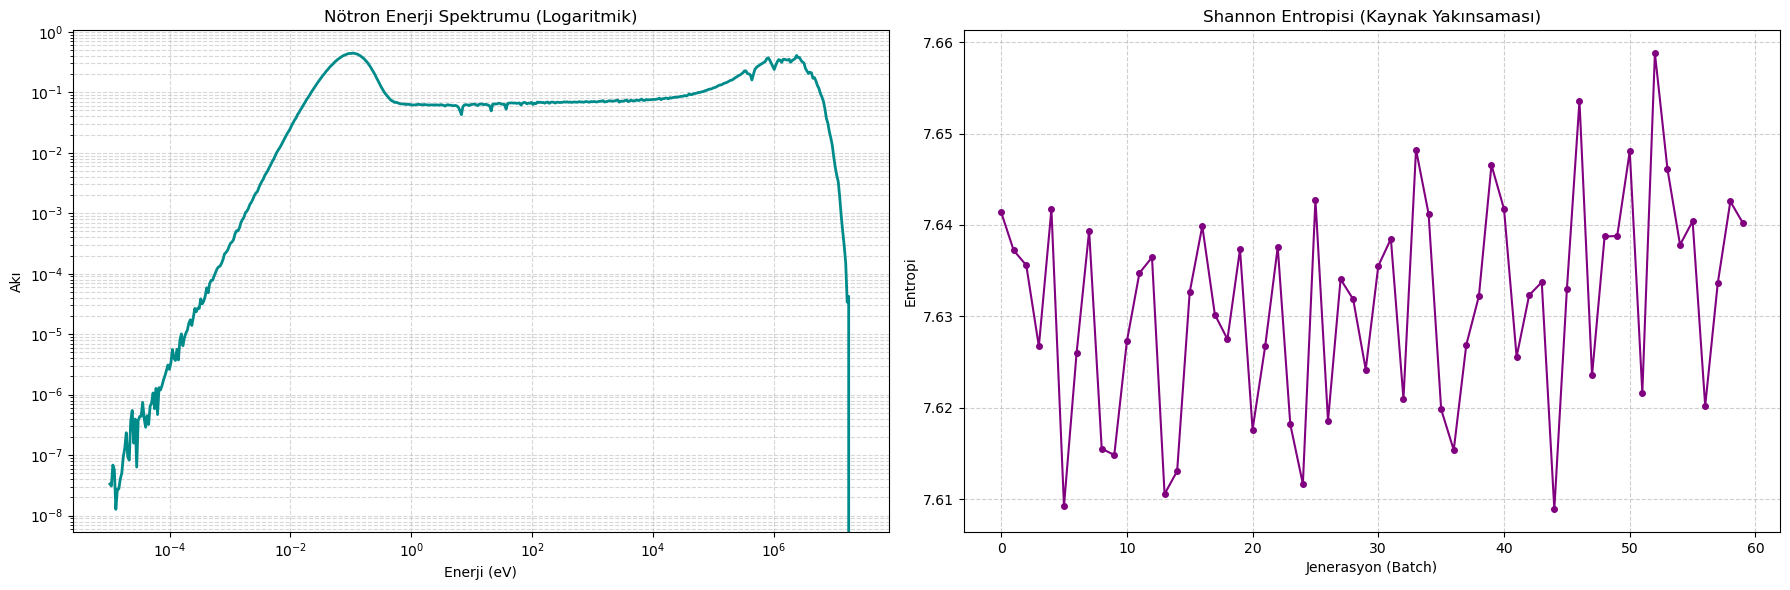

  CAREM-25 REAKSİYON İSTATİSTİKLERİ VE RAPORU
K-Effective (Sonsuz Çoğalma)  : 1.39212 +/- 0.00142
Hot Channel (Güç Zirve) Oranı : 1.997
Toplam (n,2n) Çoğalma Oranı   : 9.86037e-04
Toplam (n,gamma) Yutulma Oranı: 4.29779e-01


In [4]:
import h5py

print("\nSonuçlar HDF5 Dosyasından Analiz Ediliyor.\n")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    # 1. K-EIGENVALUE VE ENTROPİ
    k_inf = sp.keff
    entropy = sp.entropy
    
    # 2. ENERJİ SPEKTRUMU
    spec_t = sp.get_tally(name='Notron_Spektrumu')
    flux_spectrum = spec_t.mean.flatten()
    
    # 3. UZAMSAL (SPATIAL) HARİTALAR
    spatial_t = sp.get_tally(name='Uzamsal_Haritalar')
    flux_map = spatial_t.get_slice(scores=['flux']).mean.reshape((170, 170))
    fission_map = spatial_t.get_slice(scores=['fission']).mean.reshape((170, 170))
    abs_map = spatial_t.get_slice(scores=['absorption']).mean.reshape((170, 170))
    power_map = spatial_t.get_slice(scores=['kappa-fission']).mean.reshape((170, 170))
    
    # 4. KÜRESEL REAKSİYONLAR
    rxn_t = sp.get_tally(name='Global_Reaksiyonlar')
    n2n_rate = rxn_t.get_slice(scores=['(n,2n)']).mean.sum()
    ngamma_rate = rxn_t.get_slice(scores=['(n,gamma)']).mean.sum()

flux_map, fission_map, abs_map, power_map = map(np.flipud, [flux_map, fission_map, abs_map, power_map])
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

# Hot Channel Factor Hesabı
avg_power = np.mean(power_map[power_map > 0])
max_power = np.max(power_map)
hot_channel_factor = max_power / avg_power

ext = [-apothem*1.1, apothem*1.1, -apothem*1.1, apothem*1.1]

# ISI HARİTALARI (Akı, Fisyon, Soğurulma)
fig1, axes1 = plt.subplots(1, 3, figsize=(24, 7))
fig1.suptitle(f'CAREM-25 Nötronik Isı Haritaları | K_inf: {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}', fontsize=18)

im0 = axes1[0].imshow(flux_map, interpolation='nearest', cmap='jet', extent=ext)
axes1[0].set_title('Nötron Akısı (Flux)')
fig1.colorbar(im0, ax=axes1[0])

im1 = axes1[1].imshow(fission_map, interpolation='nearest', cmap='hot', extent=ext)
axes1[1].set_title('Fisyon Noktaları (Fission)')
fig1.colorbar(im1, ax=axes1[1])

im2 = axes1[2].imshow(abs_map, interpolation='nearest', cmap='viridis', extent=ext)
axes1[2].set_title('Soğurulma (Absorption) Sınırları')
fig1.colorbar(im2, ax=axes1[2])

for ax in axes1: ax.set_xlabel('X (cm)'); ax.set_ylabel('Y (cm)')
plt.tight_layout()
plt.show()

# ENERJİ SPEKTRUMU VE ENTROPİ
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))

axes2[0].loglog(energy_centers, flux_spectrum, color='darkcyan', linewidth=2)
axes2[0].set_title('Nötron Enerji Spektrumu (Logaritmik)')
axes2[0].set_xlabel('Enerji (eV)')
axes2[0].set_ylabel('Akı')
axes2[0].grid(True, which="both", ls="--", alpha=0.5)

axes2[1].plot(entropy, marker='o', color='purple', markersize=4)
axes2[1].set_title('Shannon Entropisi (Kaynak Yakınsaması)')
axes2[1].set_xlabel('Jenerasyon (Batch)')
axes2[1].set_ylabel('Entropi')
axes2[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# İSTATİSTİKSEL RAPOR
print("="*50)
print("  CAREM-25 REAKSİYON İSTATİSTİKLERİ VE RAPORU")
print("="*50)
print(f"K-Effective (Sonsuz Çoğalma)  : {k_inf.nominal_value:.5f} +/- {k_inf.std_dev:.5f}")
print(f"Hot Channel (Güç Zirve) Oranı : {hot_channel_factor:.3f}")
print(f"Toplam (n,2n) Çoğalma Oranı   : {n2n_rate:.5e}")
print(f"Toplam (n,gamma) Yutulma Oranı: {ngamma_rate:.5e}")
print("="*50)